<a href="https://colab.research.google.com/github/RegiRezende/MathCode/blob/Python_codes/DFT_X_FFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calcula a transformada discreta de Fourier DFT e FFT com uma amostra pequena e uma amostra grande. Compara resultados e tempos de cálculo.


In [11]:
import numpy as np                        #Importa a biblioteca numérica.
x = [1,1,3,1,1,0,-1,1]                  # Definir a amostra pequena.
def DFT_slow(x):                          # Define a função. O nome “slow” indica que é a versão direta O(N^2).
    x = np.asarray(x, dtype=float)        # Garante que: x é um array NumPy, com valores reais (float).
    N = x.shape[0]                        # Obtém o tamanho do sinal N.
    n = np.arange(N)                      # cria o vetor n = {0,1,2,3,...N-1}, é o índice do tempo.
    k = n.reshape((N, 1))                 # Transforma n em um vetor coluna, k.
    M = np.exp(-2j * np.pi * k * n / N)   # Constrói a matriz M: DFT escrita como matriz.
    return np.dot(M, x)                   # Faz o produto matricial

In [12]:
# Calcula a DFT usando a sua função
dft_resultado_lento = DFT_slow(x)
print(f"Resultados da DFT_slow para a amostra x: {dft_resultado_lento}")

# Calcula a FFT usando a função otimizada do NumPy
fft_resultado_numpy = np.fft.fft(x)

# Compara os resultados e exibe se são numericamente próximos
comparacao = np.allclose(dft_resultado_lento, fft_resultado_numpy)
print(f"Os resultados da DFT_slow e np.fft.fft são numericamente próximos? {comparacao}")

Resultados da DFT_slow para a amostra x: [ 7.00000000e+00+0.00000000e+00j  7.07106781e-01-4.70710678e+00j
 -5.51091060e-16+1.00000000e+00j -7.07106781e-01+3.29289322e+00j
  1.00000000e+00-8.57252759e-16j -7.07106781e-01-3.29289322e+00j
 -1.23083661e-16-1.00000000e+00j  7.07106781e-01+4.70710678e+00j]
Os resultados da DFT_slow e np.fft.fft são numericamente próximos? True


Calcula a transformada discreta de Fourier DFT e FFT com uma amostra pequena e uma amostra grande. Compara resultados e tempos de cálculo.


Calcula a transformada discreta de Fourier DFT e FFT com uma amostra pequena e uma amostra grande. Compara resultados e tempos de cálculo.


### Comparação de Performance para Amostra Pequena (x)

Vamos medir o tempo de execução para a amostra pequena 'x'.

In [13]:
import time

# Medir o tempo de execução da DFT_slow para a amostra pequena
start_time_dft_small = time.time()
dft_result_small_slow = DFT_slow(x)
end_time_dft_small = time.time()
time_dft_small = end_time_dft_small - start_time_dft_small
print(f"Tempo de execução da DFT_slow para a amostra pequena: {time_dft_small:.6f} segundos")

# Medir o tempo de execução da np.fft.fft para a amostra pequena
start_time_fft_small = time.time()
fft_result_small_numpy = np.fft.fft(x)
end_time_fft_small = time.time()
time_fft_small = end_time_fft_small - start_time_fft_small
print(f"Tempo de execução da np.fft.fft para a amostra pequena: {time_fft_small:.6f} segundos")

Tempo de execução da DFT_slow para a amostra pequena: 0.000308 segundos
Tempo de execução da np.fft.fft para a amostra pequena: 0.000167 segundos


### Comparação da Magnitude: DFT_slow vs. np.fft.fft (Amostra Pequena)

Agora vamos comparar as magnitudes dos resultados obtidos pela função `DFT_slow` e pela função otimizada `np.fft.fft` do NumPy para a amostra original `x`.

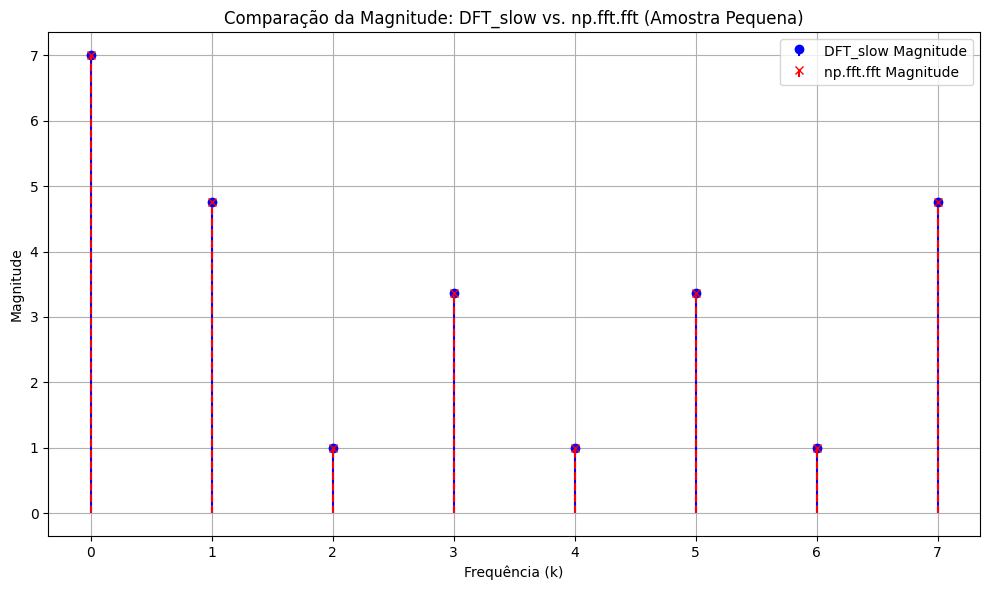

In [14]:
# Calcula a magnitude do resultado da np.fft.fft para a amostra pequena
magnitude_fft_small = np.abs(fft_resultado_numpy)

# Calcula a magnitude do resultado da DFT_slow (garantindo que esteja definida)
magnitude_dft = np.abs(dft_resultado_lento)

# Cria os índices para o eixo x (garantindo que esteja definido)
k_indices = np.arange(len(dft_resultado_lento))

# Cria a figura e os eixos para o gráfico de comparação
plt.figure(figsize=(10, 6))

# Plotagem das magnitudes
plt.stem(k_indices, magnitude_dft, linefmt='b-', markerfmt='bo', basefmt=" ", label='DFT_slow Magnitude')
plt.stem(k_indices, magnitude_fft_small, linefmt='r--', markerfmt='rx', basefmt=" ", label='np.fft.fft Magnitude')

plt.title('Comparação da Magnitude: DFT_slow vs. np.fft.fft (Amostra Pequena)')
plt.xlabel('Frequência (k)')
plt.ylabel('Magnitude')
plt.xticks(k_indices)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Comparação de Performance: DFT_slow vs. np.fft.fft

Vamos agora comparar o tempo de execução da nossa implementação `DFT_slow` com a versão otimizada `np.fft.fft` do NumPy, usando um sinal de entrada maior para observar a diferença de performance.

In [15]:
import time

# Definir um sinal de entrada maior para comparação de performance
N_large = 4096 # Um tamanho comum para FFT, geralmente uma potência de 2
x_large = np.random.rand(N_large) # Gera um sinal aleatório com N_large amostras

print(f"Executando comparação de performance para N = {N_large} amostras...")

# Medir o tempo de execução da DFT_slow
start_time_dft = time.time()
dft_result_large_slow = DFT_slow(x_large)
end_time_dft = time.time()
time_dft_slow = end_time_dft - start_time_dft
print(f"Tempo de execução da DFT_slow para N={N_large}: {time_dft_slow:.4f} segundos")

# Medir o tempo de execução da np.fft.fft
start_time_fft = time.time()
fft_result_large_numpy = np.fft.fft(x_large)
end_time_fft = time.time()
time_np_fft = end_time_fft - start_time_fft
print(f"Tempo de execução da np.fft.fft para N={N_large}: {time_np_fft:.4f} segundos")

# Verificar se os resultados são numericamente próximos (para o sinal grande também)
comparacao_large = np.allclose(dft_result_large_slow, fft_result_large_numpy)
print(f"Os resultados da DFT_slow e np.fft.fft para N={N_large} são numericamente próximos? {comparacao_large}")

Executando comparação de performance para N = 4096 amostras...
Tempo de execução da DFT_slow para N=4096: 1.6294 segundos
Tempo de execução da np.fft.fft para N=4096: 0.0005 segundos
Os resultados da DFT_slow e np.fft.fft para N=4096 são numericamente próximos? True


### Comparação da Magnitude: DFT_slow vs. np.fft.fft (Amostra Grande)

Vamos agora comparar as magnitudes dos resultados obtidos para a amostra grande `x_large`.

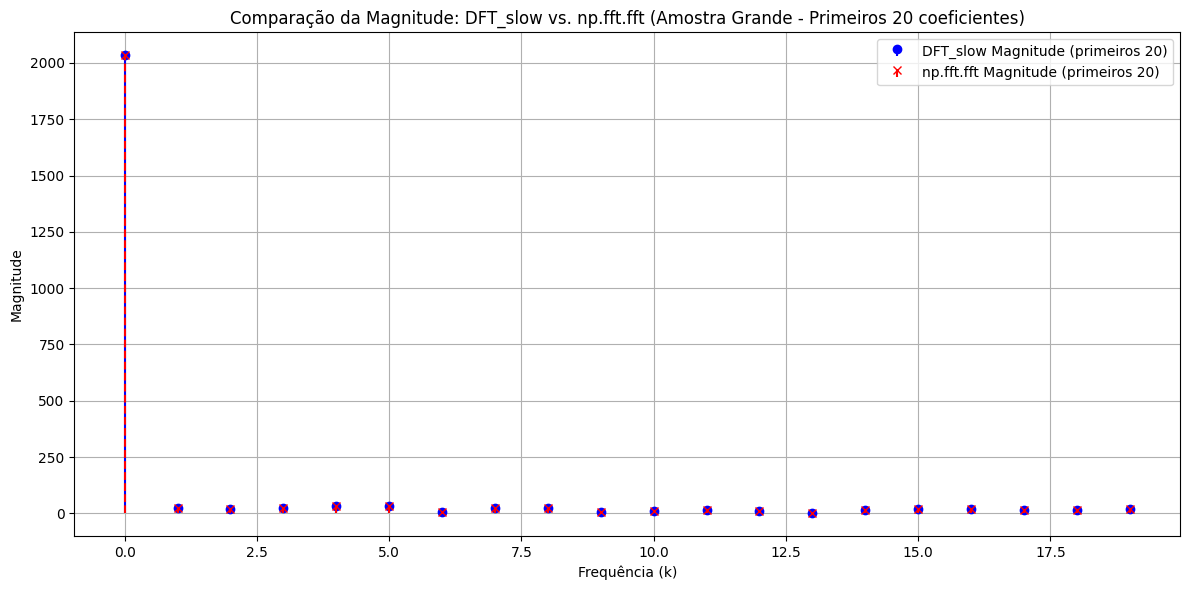

In [23]:
# Calcula a magnitude dos resultados da DFT_slow e np.fft.fft para a amostra grande
magnitude_dft_large = np.abs(dft_result_large_slow)
magnitude_fft_large = np.abs(fft_result_large_numpy)

# Cria os índices para o eixo x da amostra grande
k_indices_large = np.arange(N_large)

# Cria a figura e os eixos para o gráfico de comparação
plt.figure(figsize=(12, 6))

# Plotagem das magnitudes (apenas as primeiras 20 para visualização)
plt.stem(k_indices_large[:20], magnitude_dft_large[:20], linefmt='b-', markerfmt='bo', basefmt=" ", label='DFT_slow Magnitude (primeiros 20)')
plt.stem(k_indices_large[:20], magnitude_fft_large[:20], linefmt='r--', markerfmt='rx', basefmt=" ", label='np.fft.fft Magnitude (primeiros 20)')

plt.title('Comparação da Magnitude: DFT_slow vs. np.fft.fft (Amostra Grande - Primeiros 20 coeficientes)')
plt.xlabel('Frequência (k)')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Visualização dos Resultados da DFT

Podemos visualizar os resultados da DFT plotando a magnitude e a fase dos coeficientes de frequência.

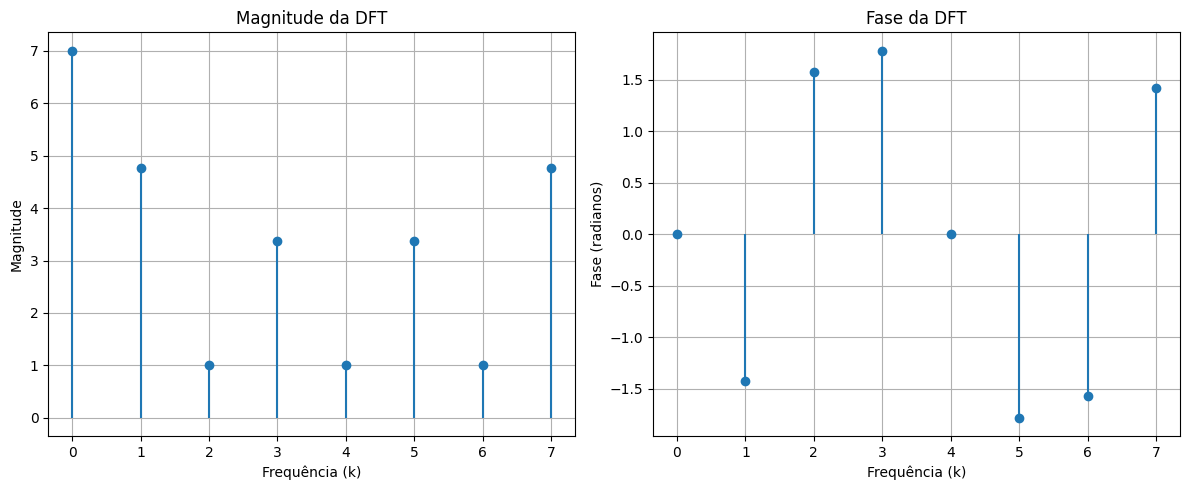

In [16]:
import matplotlib.pyplot as plt

# Calcula a magnitude e a fase dos resultados da DFT_slow
magnitude_dft = np.abs(dft_resultado_lento)
fase_dft = np.angle(dft_resultado_lento)

# Cria os índices para o eixo x
k_indices = np.arange(len(dft_resultado_lento))

# Plotagem da Magnitude
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
plt.stem(k_indices, magnitude_dft, basefmt=" ")
plt.title('Magnitude da DFT')
plt.xlabel('Frequência (k)')
plt.ylabel('Magnitude')
plt.xticks(k_indices)
plt.grid(True)

# Plotagem da Fase
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
plt.stem(k_indices, fase_dft, basefmt=" ")
plt.title('Fase da DFT')
plt.xlabel('Frequência (k)')
plt.ylabel('Fase (radianos)')
plt.xticks(k_indices)
plt.grid(True)

plt.tight_layout()
plt.show()

### Visualização do Crescimento de Complexidade: $O(N^2)$ vs. $O(N \log N)$

Para ilustrar a diferença teórica de desempenho entre a DFT "lenta" ($O(N^2)$) e a FFT ($O(N \log N)$), vamos plotar essas duas funções de complexidade para uma faixa de valores de $N$.

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_13578/3515989578.py:17: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(N_values, complexity_N_log_N, label='$O(N \log N)$ (FFT Rápida)', color='blue')
/tmp/ipykernel_13578/3515989578.py:19: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Comparação do Crescimento de Complexidade: $O(N^2)$ vs. $O(N \log N)$')
/tmp/ipykernel_13578/3515989578.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


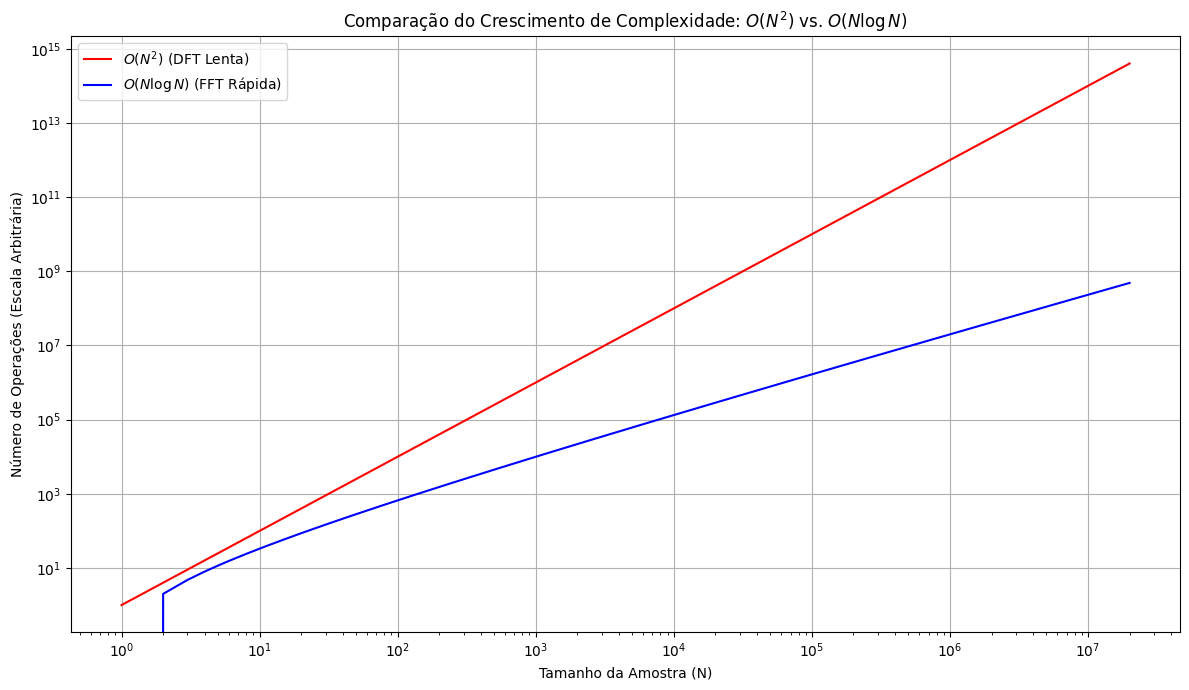

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Definir uma faixa de valores de N
N_values = np.arange(1, 20000000) # Começando de 1 para evitar log(0)

# Calcular O(N^2)
complexity_N_squared = N_values**2

# Calcular O(N log N)
# Usamos np.log2 para logaritmo na base 2, que é comum para FFT
complexity_N_log_N = N_values * np.log2(N_values)

# Criar o gráfico
plt.figure(figsize=(12, 7))
plt.plot(N_values, complexity_N_squared, label='$O(N^2)$ (DFT Lenta)', color='red')
plt.plot(N_values, complexity_N_log_N, label='$O(N \log N)$ (FFT Rápida)', color='blue')

plt.title('Comparação do Crescimento de Complexidade: $O(N^2)$ vs. $O(N \log N)$')
plt.xlabel('Tamanho da Amostra (N)')
plt.ylabel('Número de Operações (Escala Arbitrária)')
plt.legend()
plt.grid(True)
plt.yscale('log') # Usar escala logarítmica no eixo Y para melhor visualização da diferença
plt.xscale('log') # Usar escala logarítmica no eixo X
plt.tight_layout()
plt.show()